In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D, GlobalAveragePooling1D, Flatten, Conv1D, MaxPooling1D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

In [3]:
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [4]:
np.random.seed(123)
tf.random.set_seed(123)

In [5]:
df = pd.read_csv(
    r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\train\Inertial Signals\body_acc_x_train.txt',
    header = None,
    delim_whitespace = True
)

C:\Users\VARUN\AppData\Local\Temp\ipykernel_15236\3254770097.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [6]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.000181,0.010139,0.009276,0.005066,0.010810,0.004045,0.004757,0.006214,0.003307,0.007572,...,0.001412,-0.001509,0.000060,0.000435,-0.000819,0.000228,-0.000300,-0.001147,-0.000222,0.001576
1,0.001094,0.004550,0.002879,0.002247,0.003305,0.002416,0.001619,0.000981,0.000009,-0.000363,...,-0.000104,-0.000141,0.001333,0.001541,0.001077,-0.000736,-0.003767,-0.004646,-0.002941,-0.001599
2,0.003531,0.002285,-0.000420,-0.003738,-0.006706,-0.003148,0.000733,0.000668,0.002162,-0.000946,...,0.000661,0.001853,-0.000268,-0.000394,-0.000279,-0.000316,0.000144,0.001246,0.003117,0.002178
3,-0.001772,-0.001311,0.000388,0.000408,-0.000355,0.000998,0.001109,-0.003149,-0.008882,-0.010483,...,0.000458,0.002103,0.001358,0.000820,-0.000212,-0.001915,-0.001631,-0.000867,-0.001172,-0.000028
4,0.000087,-0.000272,0.001022,0.003126,0.002284,0.000885,0.001933,0.002270,0.002247,0.002175,...,0.002529,0.003518,-0.000248,-0.002761,0.000252,0.003752,0.001626,-0.000698,-0.001223,-0.003328


In [7]:
df.shape

(7352, 128)

In [8]:
''' we have N = 7352 samples and each time series has 128 measurements as explained in notes
50 recordings per second and each recording being 2.56 secs long ~2.56*50 = 128 measurements in each time series of 2.56 secs  
'''

' we have N = 7352 samples and each time series has 128 measurements as explained in notes\n50 recordings per second and each recording being 2.56 secs long ~2.56*50 = 128 measurements in each time series of 2.56 secs  \n'

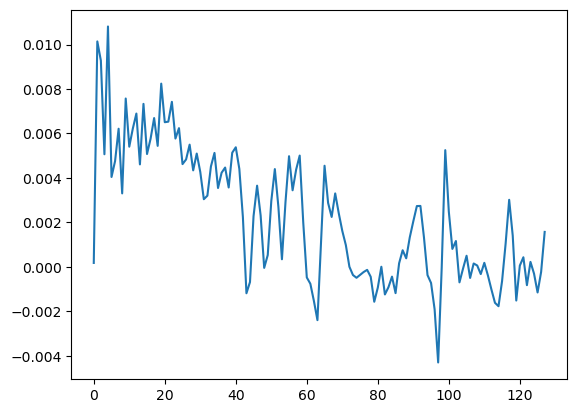

In [9]:
# plotting just 1st row or say one recording out of 7352 recordings of 2.56 seconds containing 128 measurements
df.iloc[0].plot();

# time series model using ANN

In [10]:
T = 128
Ntrain = 7352 
Ntest = 2947  # look at any data file inside G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\test\Inertial Signals
D = 9 # 9 time series
K = 6 # num of classes

In [11]:
def load_data():
    # returns:
    # Xtrain (Ntrain * T * D), Ytrain (Ntrain)
    # Xtest (Ntest * T * D), Ytest (Ntest)
    
    Xtrain = np.zeros((Ntrain, T, D))
    Xtest = np.zeros((Ntest, T, D))

    #train data
    ts_filenames = [
        'body_acc_x_train.txt', 'body_gyro_x_train.txt', 'total_acc_x_train.txt',
        'body_acc_y_train.txt', 'body_gyro_y_train.txt', 'total_acc_y_train.txt',
        'body_acc_z_train.txt', 'body_gyro_z_train.txt', 'total_acc_z_train.txt',
    ]

    ts_file_prefix = 'G:/My Drive/Study/Time Series Analysis Udemy/Data/time series analysis forecasting/UCI-HAR/UCI HAR Dataset/train/'

    for d, fn in enumerate(ts_filenames):
        df = pd.read_csv(
            f'{ts_file_prefix}Inertial Signals/{fn}',
            header = None,
            delim_whitespace = True)
        
        # Ntrain * T array
        x = df.to_numpy()
        Xtrain[:,:,d] = x

    Ytrain = pd.read_csv(f'{ts_file_prefix}/y_train.txt', header = None).to_numpy() - 1 # doing minus 1 since we want it to start from 0 instead of 1
    Ytrain = Ytrain.flatten()

    #test data
    ts_filenames = [
        'body_acc_x_test.txt', 'body_gyro_x_test.txt', 'total_acc_x_test.txt',
        'body_acc_y_test.txt', 'body_gyro_y_test.txt', 'total_acc_y_test.txt',
        'body_acc_z_test.txt', 'body_gyro_z_test.txt', 'total_acc_z_test.txt',
    ]

    ts_file_prefix = 'G:/My Drive/Study/Time Series Analysis Udemy/Data/time series analysis forecasting/UCI-HAR/UCI HAR Dataset/test/'

    for d, fn in enumerate(ts_filenames):
        df = pd.read_csv(
            f'{ts_file_prefix}Inertial Signals/{fn}',
            header = None,
            delim_whitespace = True)
        
        # Ntrain * T array
        x = df.to_numpy()
        Xtest[:,:,d] = x

    Ytest = pd.read_csv(f'{ts_file_prefix}/y_test.txt', header = None).to_numpy() - 1 # doing minus 1 since we want it to start from 0 instead of 1
    Ytest = Ytest.flatten()

    return Xtrain, Ytrain, Xtest, Ytest    
        

In [12]:
Xtrain, Ytrain, Xtest, Ytest = load_data()

C:\Users\VARUN\AppData\Local\Temp\ipykernel_15236\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_15236\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_15236\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_15236\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_15236\1734865465.py:19: FutureWarnin

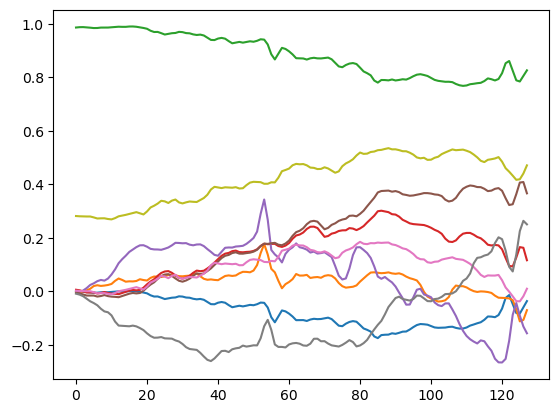

In [13]:
# plot all D time series of length T = 128 for one sample say 7000

# plt.figure(figsize =(15,5))
plt.plot(Xtrain[7000,:,:]);
# plt.show();

In [14]:
'''while building ANN, we were building 9 diff input layers and converting to ANN and then finally concatenating.
In that architecture, it learnt the local pattern first within the same time series, after concatenating from all time series
it then looks at the interactions between different time series.

CNN IS ALREADY GOOD AT HANDLING MULTIVARIATE TIME SERIES. FROM THE 1ST LAYER ITSELF IT LOOKS AT ALL THE D CHANNELS (DIFF TIME SERIES TOGETHER) 
SIMULATENOUSLY AND SLIDES THE WINDOW ACROSS T TIME STEPS, THUS LOOKING AT THE INTERACTIONS FROM THE BEGINNING

LOOK AT NOTES FOR MORE DETAILS ON THIS
'''

'while building ANN, we were building 9 diff input layers and converting to ANN and then finally concatenating.\nIn that architecture, it learnt the local pattern first within the same time series, after concatenating from all time series\nit then looks at the interactions between different time series.\n\nCNN IS ALREADY GOOD AT HANDLING MULTIVARIATE TIME SERIES. FROM THE 1ST LAYER ITSELF IT LOOKS AT ALL THE D CHANNELS (DIFF TIME SERIES TOGETHER) \nSIMULATENOUSLY AND SLIDES THE WINDOW ACROSS T TIME STEPS, THUS LOOKING AT THE INTERACTIONS FROM THE BEGINNING\n\nLOOK AT NOTES FOR MORE DETAILS ON THIS\n'

In [16]:
#CNN - it is
i = Input(shape=(T,D)) # D is like the channels in RGB where num of channels in RGB was 3
x = Conv1D(32, 3, activation='relu')(i) # slides across 3 time steps - 32 filters/channels each of dimension 3*D
x = MaxPooling1D(2)(x)
x = Conv1D(64, 3, activation='relu')(x) # slides across 3 time steps - 64 filters/channels each of dimension 3*64
x = MaxPooling1D(2)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(K)(x)
model = Model(i,x)

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 126, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 61, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,582 (127.27 KB)

 Trainable params: 32,582 (127.27 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
''' calculating num of parameters in the last conv 1d layer
128 filters for num of channels/feature maps - each filter being of size 3*num of channels in the previous layer output =  3*64
- so num of parameters   = 128 * (3*64) + 128 bias terms = 24704'''

' calculating num of parameters in the last conv 1d layer\n128 filters for num of channels/feature maps - each filter being of size 3*num of channels in the previous layer output =  3*64\n- so num of parameters   = 128 * (3*64) + 128 bias terms = 24704'

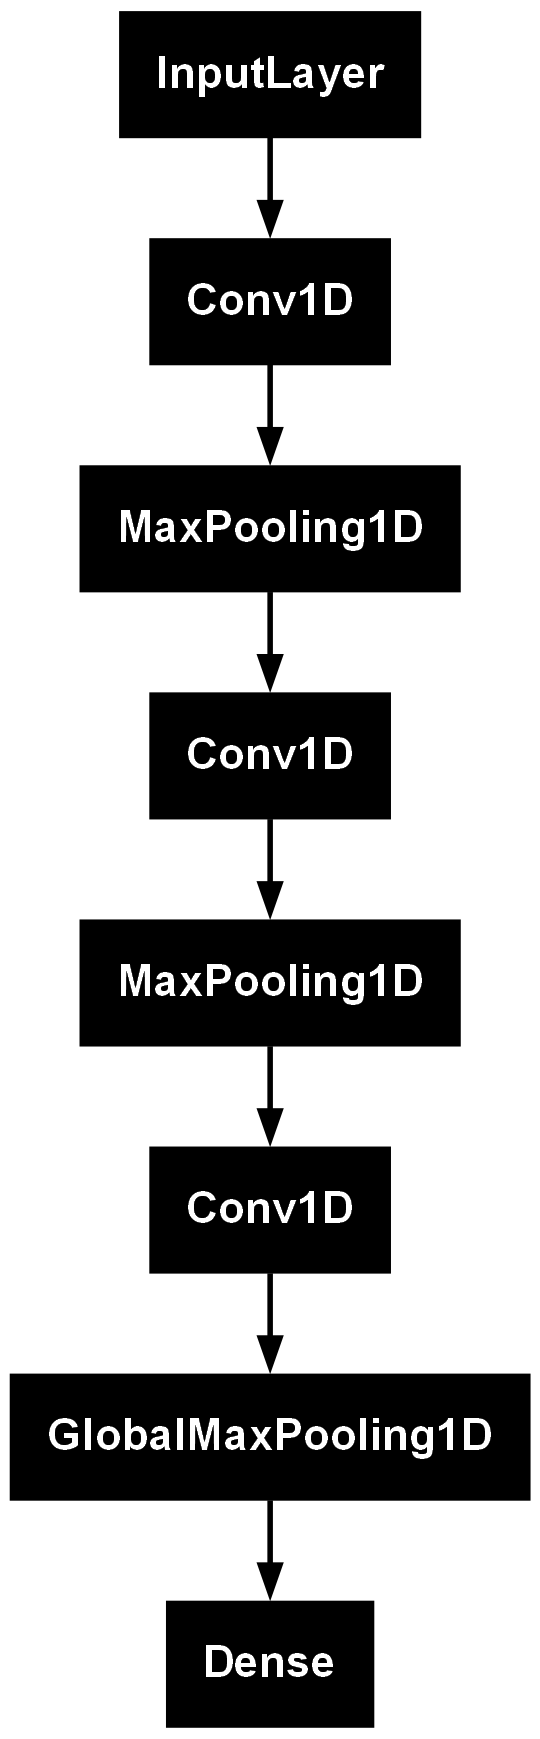

In [18]:
tf.keras.utils.plot_model(model)

In [19]:
checkpoint = ModelCheckpoint('best_model.h5', monitor ='val_accuracy', save_best_only = True)

In [21]:
model.compile(
    loss = SparseCategoricalCrossentropy(from_logits =True), 
    optimizer = 'adam',
    metrics = ['accuracy'],
)

In [22]:
r = model.fit(
    Xtrain, # note here that the Xtrain size is N x T x D, in ANN code, we had 9 different splitted X_trains each of dimension N x T
    Ytrain,
    epochs = 15,
    callbacks = [checkpoint],
    validation_data = (Xtest, Ytest))

Epoch 1/15
228/230 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7380 - loss: 0.7905 

230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8672 - loss: 0.4016 - val_accuracy: 0.8890 - val_loss: 0.3047
Epoch 2/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9500 - loss: 0.1279

230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9484 - loss: 0.1260 - val_accuracy: 0.9036 - val_loss: 0.2485
Epoch 3/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9565 - loss: 0.1070 

230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9533 - loss: 0.1106 - val_accuracy: 0.9074 - val_loss: 0.2340
Epoch 4/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9583 - loss: 0.1000 

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9550 - loss: 0.1039 - val_accuracy: 0.9074 - val_loss: 0.2272
Epoch 5/15
226/230 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9583 - loss: 0.0949 

...

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9701 - loss: 0.0719 - val_accuracy: 0.9148 - val_loss: 0.2276
Epoch 11/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9739 - loss: 0.0630 

230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9721 - loss: 0.0668 - val_accuracy: 0.9125 - val_loss: 0.2597
Epoch 12/15
225/230 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9756 - loss: 0.0586 

230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9744 - loss: 0.0620 - val_accuracy: 0.9158 - val_loss: 0.2727
Epoch 13/15
226/230 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9768 - loss: 0.0548 

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9765 - loss: 0.0572 - val_accuracy: 0.9128 - val_loss: 0.3236
Epoch 14/15
227/230 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9798 - loss: 0.0490 

230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9788 - loss: 0.0513 - val_accuracy: 0.9165 - val_loss: 0.3147
Epoch 15/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9765 - loss: 0.0602 - val_accuracy: 0.9203 - val_loss: 0.3247


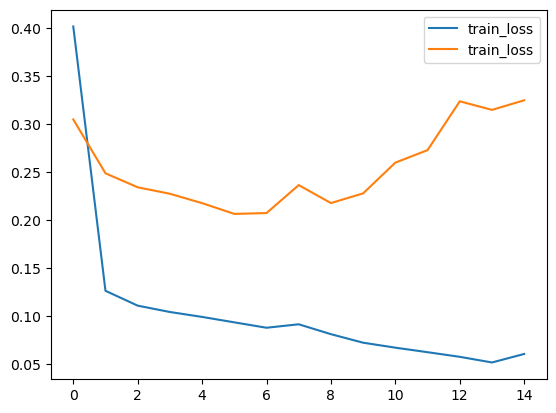

In [23]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'train_loss')
plt.legend();

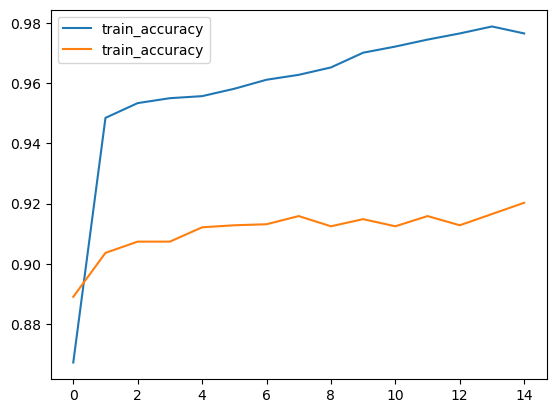

In [24]:
plt.plot(r.history['accuracy'], label = 'train_accuracy')
plt.plot(r.history['val_accuracy'], label = 'train_accuracy')
plt.legend();

In [25]:
# load best model
best_model = tf.keras.models.load_model('best_model.h5')

In [26]:
# make predictions
ptest = best_model.predict(Xtest)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   


In [28]:
print(ptest.shape)
print(ptest[0].shape)

(2947, 6)
(6,)


In [29]:
#evaluate
np.mean(np.argmax(ptest, axis = 1)==Ytest)

np.float64(0.9165252799457075)

In [55]:
'''this seems like a very decent result, but we need a point of comparison or baseline.
although, there a model which we build using ANN which took each time series as parallel inputs (total 9)
which showed better results than this CNN
'''

'this seems like a very decent result, but we need a point of comparison or baseline.\nalthough, there a model which we build using ANN which took each time series as parallel inputs (total 9)\nwhich showed better results than this CNN\n'

# comparing this with a combined model containing inputs from the raw time series as well as the precomputed features from the same time series as an input

In [32]:
''' note that we are going to use a file containing pre extracted features which we are not going to compute. this is already done using
the original time series showed in the above section'''

' note that we are going to use a file containing pre extracted features which we are not going to compute. this is already done using\nthe original time series showed in the above section'

In [33]:
from sklearn.preprocessing import StandardScaler

def load_features():
    # returns 
    # X_train (Ntrain X D)
    # X_test (Ntest X D)

    # train data
    df = pd.read_csv(
        r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\train\X_train.txt',
        header = None,
        delim_whitespace = True)
    # these features are already precomputed from the original time series explained in the section above

    feat_train = df.to_numpy()

    #test data
    df = pd.read_csv(
        r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\test\X_test.txt',
        header = None,
        delim_whitespace = True)

    feat_test = df.to_numpy()

    scaler = StandardScaler()
    feat_train = scaler.fit_transform(feat_train)
    feat_test = scaler.transform(feat_test)

    return feat_train, feat_test  



In [34]:
feat_train, feat_test = load_features()

C:\Users\VARUN\AppData\Local\Temp\ipykernel_15236\1250225645.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_15236\1250225645.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [35]:
feat_train.shape

(7352, 561)

In [36]:
D_feat = feat_train.shape[1]
D_feat #this is the number of columns in the features

561

In [40]:
# combined model using time series and already extracted features 

#CNN
i = Input(shape=(T,D)) # D is like the channels in RGB where num of channels in RGB was 3
x = Conv1D(32, 3, activation='relu')(i) # slides across 3 time steps - 32 filters/channels each of dimension 3*D
x = MaxPooling1D(2)(x)
x = Conv1D(64, 3, activation='relu')(x) # slides across 3 time steps - 64 filters/channels each of dimension 3*64
x = MaxPooling1D(2)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)

#ANN
i2 = Input(shape=(D_feat,))
x2 = Dense(64, activation ='relu')(i2)

x = Concatenate()([x, x2])
x = Dense(K)(x)

model = Model([i, i2],x)

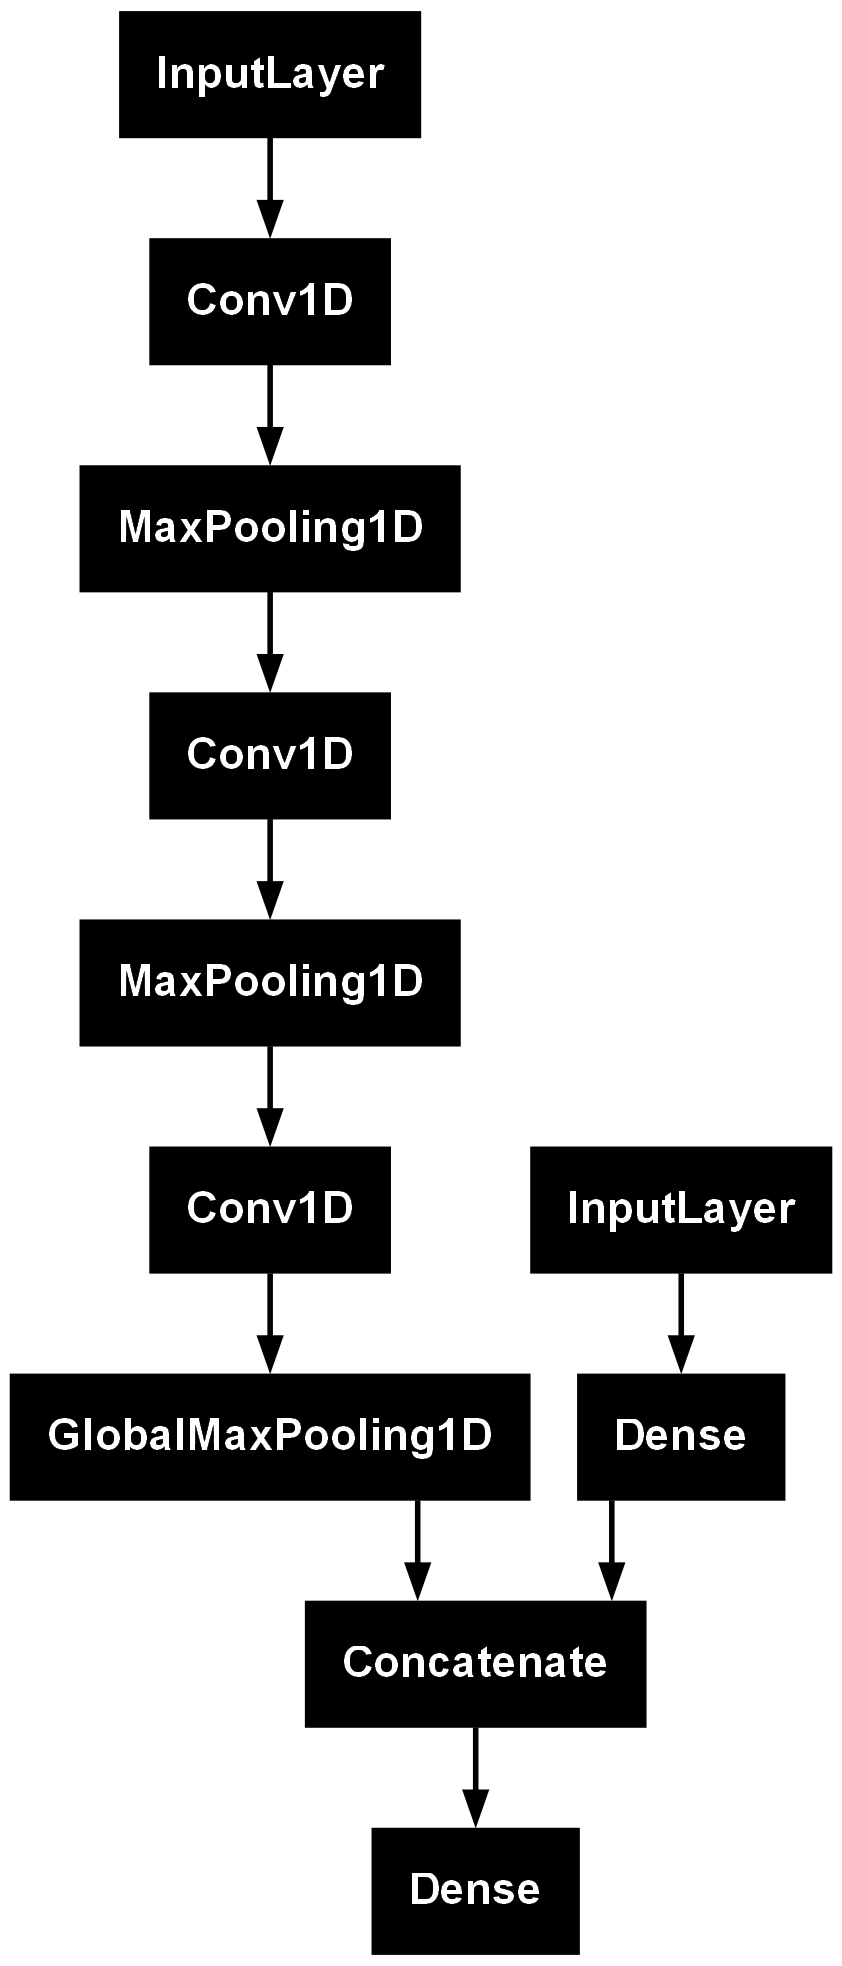

In [42]:
tf.keras.utils.plot_model(model)

In [43]:
check_point3 = ModelCheckpoint('best_model_combined.h5', monitor = 'val_accuracy', save_best_only=True)

In [44]:
model.compile(
    loss = SparseCategoricalCrossentropy(from_logits = True),
    optimizer = 'adam',
    metrics =['accuracy'],)
    

In [47]:
r = model.fit(
    [Xtrain, feat_train],
    Ytrain,
    epochs = 15,
    callbacks = [check_point3],
    validation_data = ([Xtest, feat_test], Ytest),)

Epoch 1/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8335 - loss: 0.4628

230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9204 - loss: 0.2235 - val_accuracy: 0.9511 - val_loss: 0.1342
Epoch 2/15
228/230 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9727 - loss: 0.0722

230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9739 - loss: 0.0683 - val_accuracy: 0.9569 - val_loss: 0.1154
Epoch 3/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9786 - loss: 0.0517 - val_accuracy: 0.9542 - val_loss: 0.1181
Epoch 4/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9825 - loss: 0.0432 - val_accuracy: 0.9542 - val_loss: 0.1284
Epoch 5/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9849 - loss: 0.0372 - val_accuracy: 0.9549 - val_loss: 0.1328
Epoch 6/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9871 - loss: 0.0329 - val_accuracy: 0.9528 - val_loss: 0.1511
Epoch 7/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9899 - loss: 0.0283 - val_accuracy: 0.9532 - val_loss: 0.1598
Epoch 8/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9922 - loss: 0.0243 - val_accuracy: 0.9522 - val_loss: 0.1653
Epoch 9/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9929 - loss: 0.0209 - val_accuracy: 0.952

230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9937 - loss: 0.0160 - val_accuracy: 0.9583 - val_loss: 0.1507


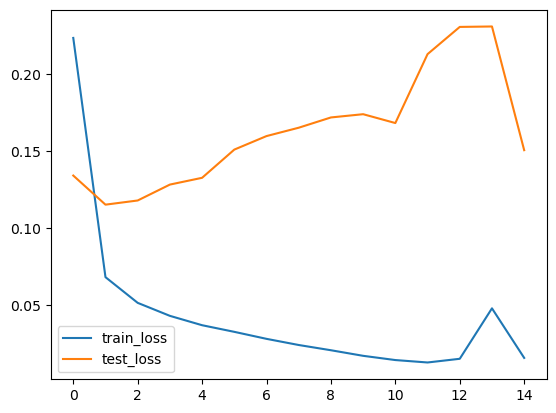

In [48]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

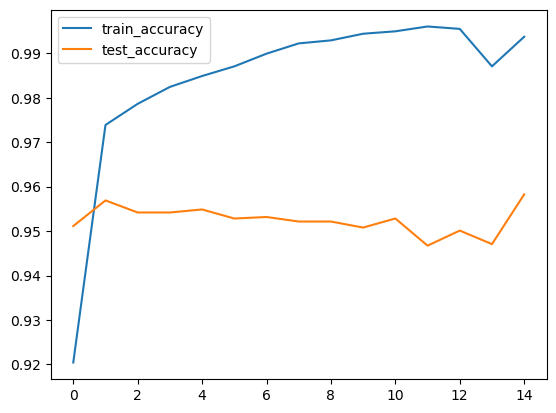

In [49]:
plt.plot(r.history['accuracy'], label = 'train_accuracy')
plt.plot(r.history['val_accuracy'], label = 'test_accuracy')
plt.legend();

In [50]:
#load best model
best_model = tf.keras.models.load_model('best_model_combined.h5')

In [51]:
#make predictions
ptest = best_model.predict([Xtest, feat_test])

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step 


In [53]:
#evaluate
np.mean(np.argmax(ptest, axis=1)==Ytest)

np.float64(0.9582626399728538)

In [54]:
''' this is much better than the time series model.

also looking at the combined model (done in a separate notebook) built using ANNs only and not using CNN, this model using CNN performs 
slightly better

However, the best model was logistic regression model done in the previous notebook which used just the features extracted from the time series
'''


' this is much better than the time series model.\n\nalso looking at the combined model (done in a separate notebook) built using ANNs only and not using CNN, this model using CNN performs \nslightly better\n\nHowever, the best model was logistic regression model done in the previous notebook which used just the features extracted from the time series\n'